Task 4: Full EDA Pipeline — Food Delivery Insights (NumPy)

- Build an end-to-end exploratory analysis pipeline that generates, cleans, enriches, and visualises a synthetic food delivery dataset using all four modules in sequence.

- Use NumPy (seed=7) to generate a 200-row dataset with columns: order_value (uniform Rs 100–Rs 800), distance_km (uniform 1–20), delivery_time_mins (normal ?=30, ?=8), rating (uniform 1.0–5.0), and discount_pct (uniform 0–30); load it into a Pandas DataFrame

In [4]:
import numpy as np
import pandas as pd

np.random.seed(7)

data = {
    "order_value": np.random.uniform(100, 800, 200),

    "distance_km": np.random.uniform(1, 20, 200),

    "delivery_time_mins": np.random.normal(
        loc=30,
        scale=8,
        size=200
    ),

    "rating": np.random.uniform(1.0, 5.0, 200),

    "discount_pct": np.random.uniform(0, 30, 200)
}

df = pd.DataFrame(data)
print(df)

     order_value  distance_km  delivery_time_mins    rating  discount_pct
0     153.415803    15.287118           29.436359  1.610398     17.079069
1     645.943155     2.171641           41.143419  1.247733      4.256927
2     406.886462    15.151650           20.002291  3.285994     18.347489
3     606.425624    18.979243           18.019293  1.749068     29.233717
4     784.592658    12.467631           24.767687  3.171931      8.202608
..           ...          ...                 ...       ...           ...
195   451.264824    18.616958           14.989387  2.738598     18.982758
196   745.822207    11.297294           33.823406  3.576348     11.126439
197   367.757797     5.591340           27.490924  4.840376      2.385037
198   555.089830     9.306737           23.154610  2.077615      8.599132
199   516.934779    18.006834           33.985596  2.571456     20.803693

[200 rows x 5 columns]


- Artificially introduce 5% null values into the delivery_time_mins and rating columns using np.random.choice(); then fill all nulls with the respective column medians.

In [5]:
# Number of null values = 5% of 200 = 10
n_null = int(len(df) * 0.05)

# 5% null values

# 10 row indexes for delivery_time_mins
delivery_null_indices = np.random.choice(
    df.index,
    size=n_null,
    replace=False
)

# Randomly select 10 row indexes for rating
rating_null_indices = np.random.choice(
    df.index,
    size=n_null,
    replace=False
)

# Set selected values to NaN
df.loc[delivery_null_indices, "delivery_time_mins"] = np.nan
df.loc[rating_null_indices, "rating"] = np.nan

# Check null values
print("Null values before filling:")
print(df[["delivery_time_mins", "rating"]].isnull().sum())


# -----------------------------
# Fill nulls with medians
# -----------------------------

delivery_median = df["delivery_time_mins"].median()
rating_median = df["rating"].median()

df["delivery_time_mins"] = df["delivery_time_mins"].fillna(
    delivery_median
)

df["rating"] = df["rating"].fillna(
    rating_median
)


# -----------------------------
# Check final result
# -----------------------------

print("\nDelivery Time Median:", delivery_median)
print("Rating Median:", rating_median)

print("\nNull values after filling:")
print(df[["delivery_time_mins", "rating"]].isnull().sum())

Null values before filling:
delivery_time_mins    10
rating                10
dtype: int64

Delivery Time Median: 29.057837919784134
Rating Median: 3.033249347272907

Null values after filling:
delivery_time_mins    0
rating                0
dtype: int64


In [6]:
# delivery speed in km/h
df["delivery_speed_kmph"] = (
    df["distance_km"] / (df["delivery_time_mins"] / 60)
)

# 3 equal-frequency speed bands
df["speed_band"] = pd.qcut(
    df["delivery_speed_kmph"],
    q=3,
    labels=["Slow", "Normal", "Fast"]
)

print(df)

     order_value  distance_km  delivery_time_mins    rating  discount_pct  \
0     153.415803    15.287118           29.436359  1.610398     17.079069   
1     645.943155     2.171641           41.143419  1.247733      4.256927   
2     406.886462    15.151650           20.002291  3.033249     18.347489   
3     606.425624    18.979243           18.019293  3.033249     29.233717   
4     784.592658    12.467631           24.767687  3.171931      8.202608   
..           ...          ...                 ...       ...           ...   
195   451.264824    18.616958           14.989387  2.738598     18.982758   
196   745.822207    11.297294           33.823406  3.576348     11.126439   
197   367.757797     5.591340           27.490924  4.840376      2.385037   
198   555.089830     9.306737           23.154610  2.077615      8.599132   
199   516.934779    18.006834           29.057838  2.571456     20.803693   

     delivery_speed_kmph speed_band  
0              31.159664       Fast  

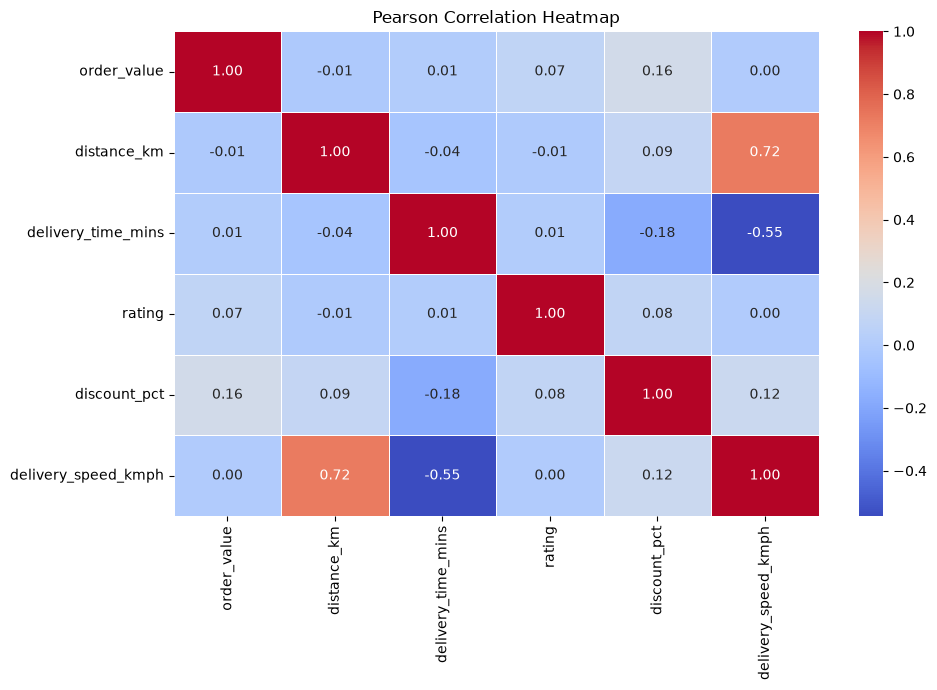

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df.select_dtypes(include="number")

corr_matrix = num_df.corr(method="pearson")

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()

# Save the heatmap
plt.savefig(
    "correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

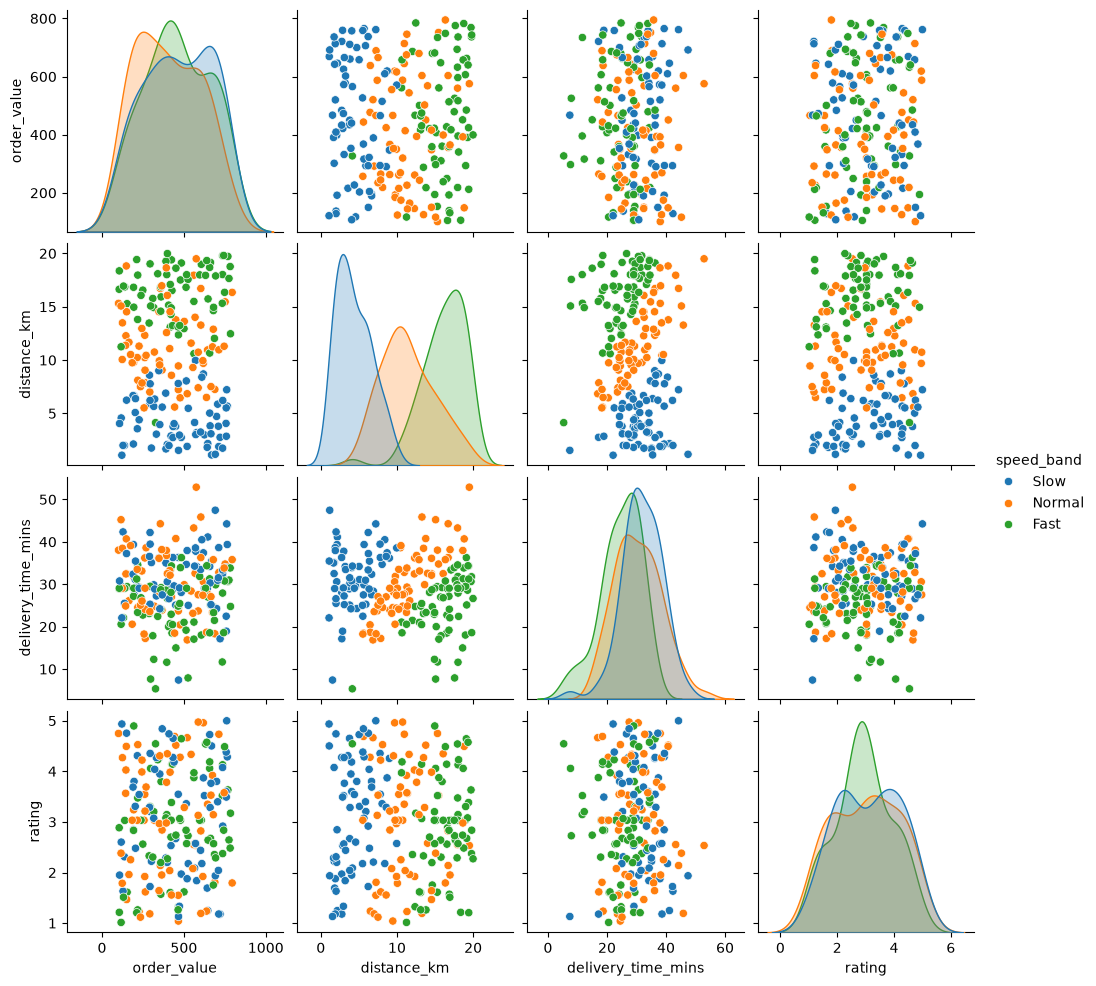

In [13]:
pairplot_data = df[
    [
        "order_value",
        "distance_km",
        "delivery_time_mins",
        "rating",
        "speed_band"
    ]
]

# pairplot
g = sns.pairplot(
    pairplot_data,
    vars=[
        "order_value",
        "distance_km",
        "delivery_time_mins",
        "rating"
    ],
    hue="speed_band"
)

# Save Plot
plt.savefig(
    "pairplot.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()